# Feature Importance

## Overview

This notebook demonstrates the public functions in `feature_importance` on a synthetic classification experiment.
- The notebook creates informative, redundant, and noise features with known column prefixes.
- It computes orthogonalized features and compares MDI, MDA, and SFI importance estimates.
- It visualizes importance allocations by feature group and by individual feature.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(31)

In [2]:
from src.strategy_modeling.feature_importance import (
    get_feature_importance,
    get_mda_feature_importance,
    get_mdi_feature_importance,
    get_orthogonal_features,
    get_single_feature_importance,
    get_test_data,
    plot_feature_importance,
)

## Load Synthetic Feature Data

This section uses `get_test_data` to create a controlled feature-importance problem.
- `I_` columns are informative features.
- `R_` columns are redundant linear combinations of the informative signal.
- `N_` columns are noise features and provide a sanity check for each method.

In [3]:
trnsX, cont = get_test_data(
    n_features=12,
    n_informative=4,
    n_redundant=3,
    n_samples=300,
    random_state=31,
)

data_summary = pd.Series(
    {
        "num_samples": trnsX.shape[0],
        "num_features": trnsX.shape[1],
        "informative_features": trnsX.columns.str.startswith("I_").sum(),
        "redundant_features": trnsX.columns.str.startswith("R_").sum(),
        "noise_features": trnsX.columns.str.startswith("N_").sum(),
        "positive_label_rate": cont["bin"].mean(),
    }
)
data_summary

num_samples             300.0
num_features             12.0
informative_features      4.0
redundant_features        3.0
noise_features            5.0
positive_label_rate       0.5
dtype: float64

### Interpretation

The test table gives the importance routines a known target structure.
- The current run has `300` samples and `12` features: `4` informative, `3` redundant, and `5` noise columns.
- The label rate is close to balanced, so feature rankings are not dominated by a trivial majority-class baseline.
- Because the redundant columns contain signal derived from informative columns, a good method may allocate importance to both `I_` and `R_` groups.

## Orthogonalize Features

This section runs the PCA-style helper before estimating importance.
- `get_orthogonal_features` standardizes the features and keeps enough eigen components to pass the variance threshold.
- The retained components provide a compact view of how much dimensionality is needed to describe the feature matrix.

In [4]:
orthogonal_features = get_orthogonal_features(trnsX, varThres=0.90)

print(f"original shape: {trnsX.shape}")
print(f"orthogonal shape: {orthogonal_features.shape}")
orthogonal_features.head()

original shape: (300, 12)
orthogonal shape: (300, 8)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
2000-01-01,-1.104937,-0.147272,-0.365563,0.846235,0.036893,1.688204,0.049060,0.466984
2000-01-02,0.416249,1.219169,-0.772527,-0.743417,-0.033793,-0.008686,0.873485,0.538271
2000-01-03,-1.919881,-0.130069,-1.165943,-0.245234,-0.265942,0.547235,0.148583,-0.843349
2000-01-04,0.729802,2.170342,0.172703,0.771881,-1.982010,1.348457,-2.179923,0.379398
2000-01-05,-2.123163,2.823757,0.079157,-0.336936,-0.252272,-1.429738,-0.057303,1.624793


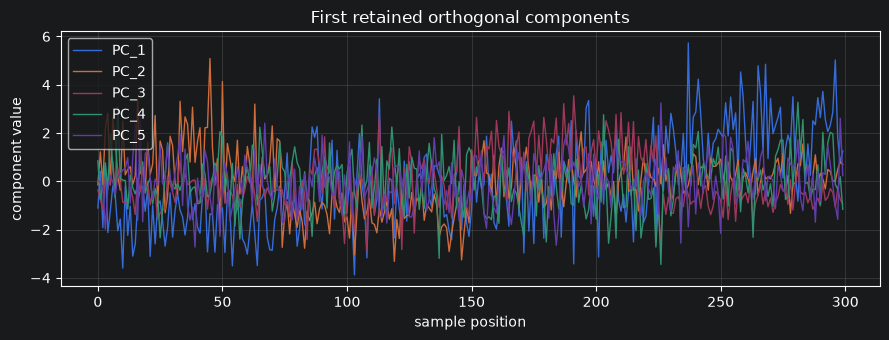

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
component_view = orthogonal_features.iloc[:, : min(5, orthogonal_features.shape[1])].reset_index(drop=True)
component_view.plot(ax=ax, lw=1)
ax.set_title("First retained orthogonal components")
ax.set_xlabel("sample position")
ax.set_ylabel("component value")
ax.grid(alpha=0.25)
fig.tight_layout()

### Interpretation

The orthogonal feature projection reduces the 12-column input to `8` retained components at the 90% variance threshold.
- This indicates that the synthetic redundant features do create measurable overlap in the original feature matrix.
- The component plot is centered and oscillates around zero because the helper standardizes each input feature before decomposition.
- The retained component count is a diagnostic; the importance comparisons below still use the original named features so the `I_`, `R_`, and `N_` groups remain readable.

## Compare MDI, MDA, And SFI

This section runs the three importance methods through `get_feature_importance`.
- MDI uses fitted tree impurity reductions.
- MDA permutes each feature in purged cross-validation folds and measures score deterioration.
- SFI scores one feature at a time under the same purged cross-validation setup.

In [6]:
importance_results = {}
summary_rows = []

for method in ["MDI", "MDA", "SFI"]:
    imp, oob, oos = get_feature_importance(
        trnsX=trnsX,
        cont=cont,
        n_estimators=30,
        cv=3,
        max_samples=1.0,
        numThreads=1,
        pctEmbargo=0,
        scoring="accuracy",
        method=method,
        random_state=31,
    )
    importance_results[method] = {"imp": imp, "oob": oob, "oos": oos}
    grouped = imp["mean"].groupby(imp.index.str[0]).sum()
    summary_rows.append(
        {
            "method": method,
            "I_total": grouped.get("I", 0.0),
            "R_total": grouped.get("R", 0.0),
            "N_total": grouped.get("N", 0.0),
            "oob": oob,
            "oos": oos,
            "top_feature": imp["mean"].idxmax(),
            "top_importance": imp["mean"].max(),
        }
    )

importance_summary = pd.DataFrame(summary_rows).set_index("method")
importance_summary

,I_total,R_total,N_total,oob,oos,top_feature,top_importance
method,,,,,,,
MDI,0.382145,0.394966,0.222889,0.873333,0.593333,R_2,0.219162
MDA,0.030968,0.152148,-0.115087,0.873333,0.593333,R_2,0.253836
SFI,1.883333,1.440000,2.206667,0.873333,0.593333,I_0,0.716667


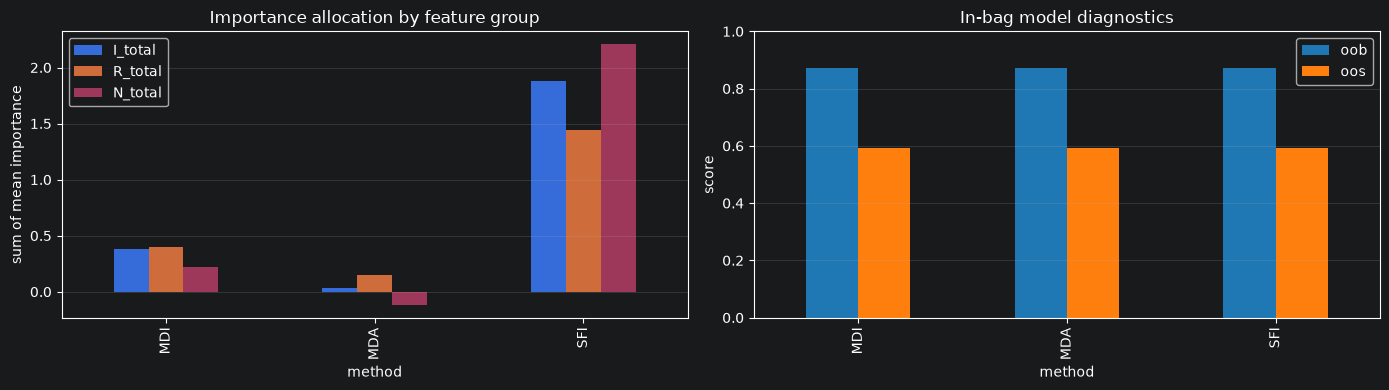

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

importance_summary[["I_total", "R_total", "N_total"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Importance allocation by feature group")
axes[0].set_xlabel("method")
axes[0].set_ylabel("sum of mean importance")
axes[0].grid(axis="y", alpha=0.25)

importance_summary[["oob", "oos"]].plot(kind="bar", ax=axes[1], color=["tab:blue", "tab:orange"])
axes[1].set_title("In-bag model diagnostics")
axes[1].set_xlabel("method")
axes[1].set_ylabel("score")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()

### Interpretation

The three methods agree that signal is not isolated to one original feature group, but they express scale differently.
- MDI assigns about `0.3821` to informative columns and `0.3950` to redundant columns, with `R_2` as the top feature at `0.2192`.
- MDA reports positive deterioration for informative and redundant groups but slightly negative total noise contribution (`-0.0307`), which means some noise permutations happened to improve fold scores in this small sample.
- SFI scores features independently, so its group totals are not normalized like MDI; its top feature is `I_0` with an isolated score of `0.7167`.

## Plot Individual Importance Profiles

This section displays the per-feature mean and uncertainty estimates for each method.
- MDI and MDA are easiest to read as relative importance estimates.
- SFI is a single-feature score, so higher values indicate a stronger standalone predictor rather than a share of total model importance.

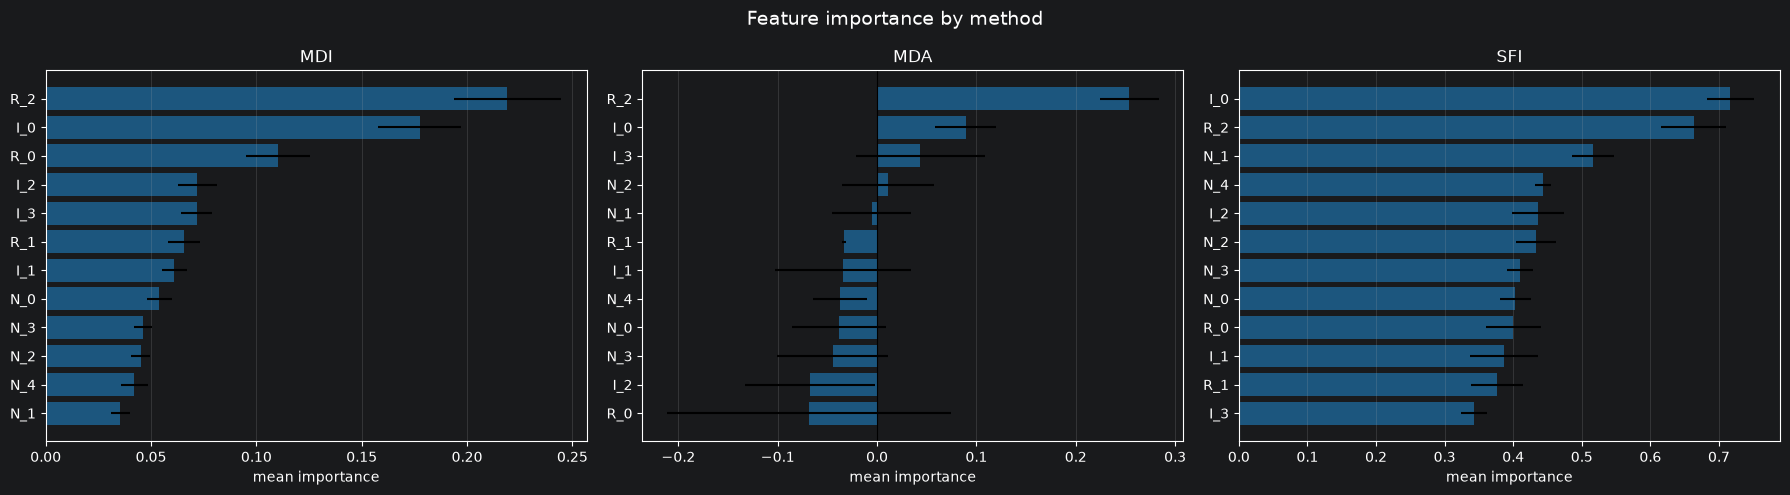

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, method in zip(axes, ["MDI", "MDA", "SFI"]):
    imp = importance_results[method]["imp"].sort_values("mean")
    ax.barh(imp.index, imp["mean"], xerr=imp["std"], color="tab:blue", alpha=0.65)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(method)
    ax.set_xlabel("mean importance")
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("Feature importance by method", fontsize=14)
fig.tight_layout()

### Interpretation

The per-feature plots expose the main behavioral difference between the methods.
- MDI concentrates importance in a few tree-friendly columns and keeps all bars non-negative by construction.
- MDA can be negative when a shuffled feature improves validation performance, which is why small negative noise bars are meaningful diagnostics rather than plotting errors.
- SFI favors features that work alone; that is why a redundant feature can rank lower there even when it receives meaningful MDI/MDA importance inside a multifeature model.